# Metabolic Phenotyping

This notebook identifies data-driven metabolic phenotypes within the prepared NHANES analysis cohort using unsupervised clustering.

The analysis cohort is first divided into training and test sets. Phenotype discovery, including standardization, selection of the number of clusters and fitting of the K-means model, is performed using the training set only. The fitted preprocessing and clustering models are then applied to the held-out test set without refitting.

This ensures that the test data do not influence phenotype discovery before subsequent evaluation of the predictive models.

CAP and hepatic steatosis status are not used as clustering variables.

## Loading the analysis cohort and selecting clustering variables

The prepared analysis cohort from `01-data-preparation.ipynb` is loaded from `analysis_cohort.csv`.

Variables representing several metabolic domains are selected for clustering: BMI and waist circumference represent general and central adiposity; systolic and diastolic blood pressure represent cardiovascular status; HDL and triglycerides represent lipid metabolism; and fasting glucose represents glucose regulation.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split

DATA_PATH = Path("../data/processed/analysis_cohort.csv")
PROCESSED_DIR = Path("../data/processed")

df = pd.read_csv(DATA_PATH)

cluster_features = [
    "bmi",
    "waist_cm",
    "systolic_bp",
    "diastolic_bp",
    "hdl_mg_dl",
    "triglycerides_mg_dl",
    "glucose_mg_dl",
]

print(f"Participants: {len(df):,}")
print(f"Clustering variables: {len(cluster_features)}")

df[cluster_features].describe().T

Participants: 3,270
Clustering variables: 7


,count,mean,std,min,25%,50%,75%,max
bmi,3270.0,29.486911,7.032075,15.400000,24.500000,28.300000,33.175000,65.3
waist_cm,3270.0,99.657370,16.874911,61.100000,87.425000,98.400000,110.400000,169.5
systolic_bp,3270.0,123.435933,18.523845,78.666667,110.000000,120.666667,133.333333,214.0
diastolic_bp,3270.0,74.176198,11.259667,41.333333,66.333333,73.333333,81.333333,126.0
hdl_mg_dl,3270.0,53.376758,15.729180,11.000000,42.000000,51.000000,61.000000,187.0
triglycerides_mg_dl,3270.0,109.311621,95.838413,10.000000,59.250000,88.000000,131.000000,2684.0
glucose_mg_dl,3270.0,112.443425,36.877917,47.000000,96.000000,103.000000,114.000000,451.0


## Creating the training and test sets

The analysis cohort is divided into training and test sets before any data-driven preprocessing or clustering is performed.

A stratified split is used to preserve approximately the same hepatic steatosis outcome distribution in both sets. The training set is used for phenotype discovery and subsequent model development, while the test set remains held out for final model evaluation.

Although hepatic steatosis status is used to stratify the split, it is not used as an input to the clustering algorithm.

In [2]:
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["hepatic_steatosis"],
)

train_df = train_df.copy()
test_df = test_df.copy()

print(f"Full cohort:  {len(df):,}")
print(f"Training set: {len(train_df):,}")
print(f"Test set:     {len(test_df):,}")

print("\nSteatosis prevalence:")
print(f"Training: {train_df['hepatic_steatosis'].mean() * 100:.1f}%")
print(f"Test:     {test_df['hepatic_steatosis'].mean() * 100:.1f}%")

Full cohort:  3,270
Training set: 2,616
Test set:     654

Steatosis prevalence:
Training: 57.6%
Test:     57.5%


## Standardizing metabolic variables

The selected metabolic variables are measured using different units and numerical scales. Because K-means is distance-based, variables with larger numerical ranges could otherwise have greater influence on the resulting clusters.

`StandardScaler` is therefore fitted using the training data only, transforming each metabolic variable relative to the training-set mean and standard deviation.

The fitted scaler is later applied unchanged to the test set. The test data are not used to estimate the scaling parameters, preventing information from the held-out test set from influencing phenotype discovery.

In [3]:
scaler = StandardScaler()

X_train_cluster = scaler.fit_transform(
    train_df[cluster_features]
)

X_train_cluster = pd.DataFrame(
    X_train_cluster,
    columns=cluster_features,
    index=train_df.index,
)

X_train_cluster.describe().round(2)

,bmi,waist_cm,systolic_bp,diastolic_bp,hdl_mg_dl,triglycerides_mg_dl,glucose_mg_dl
count,2616.00,2616.00,2616.00,2616.00,2616.00,2616.00,2616.00
mean,-0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.01,-2.29,-2.45,-2.95,-2.67,-1.01,-1.71
25%,-0.71,-0.74,-0.72,-0.71,-0.73,-0.51,-0.45
50%,-0.15,-0.08,-0.15,-0.08,-0.17,-0.21,-0.27
75%,0.53,0.64,0.51,0.63,0.46,0.22,0.02
max,5.12,4.15,4.95,4.27,8.36,26.51,8.67


## Determining the number of metabolic phenotypes

K-means clustering requires the number of clusters (`k`) to be specified before fitting the final model. Candidate solutions from one to six clusters are therefore compared using the elbow method and silhouette analysis.

The elbow method examines within-cluster inertia, with a substantial reduction followed by diminishing improvements suggesting a suitable number of clusters. Silhouette analysis evaluates how well participants are separated between clusters, with higher values indicating greater separation.

Silhouette scores require at least two clusters and are therefore calculated only for `k = 2` through `k = 6`.

,k,inertia,silhouette
0,1,18312.000000,NaN
1,2,14069.035005,0.241958
2,3,12363.104353,0.240030
3,4,10802.675376,0.222997
4,5,9739.285563,0.190149
5,6,8803.014203,0.190776


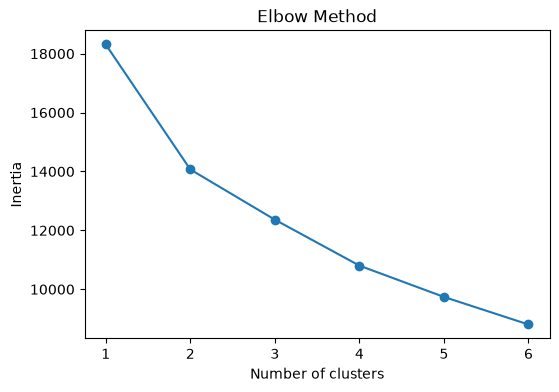

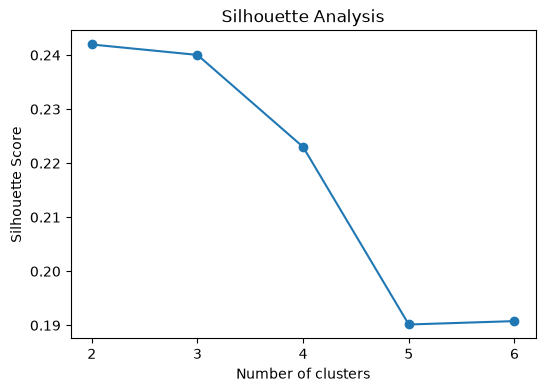

In [4]:
# Compare possible numbers of clusters

results = []

for k in range(1, 7):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20,
    )

    labels = model.fit_predict(X_train_cluster)

    results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": (
            silhouette_score(X_train_cluster, labels)
            if k > 1 else None
        ),
    })

cluster_results = pd.DataFrame(results)

display(cluster_results)

# Elbow method: k = 1–6
plt.figure(figsize=(6, 4))
plt.plot(
    cluster_results["k"],
    cluster_results["inertia"],
    marker="o"
)
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(range(1, 7))
plt.show()

# Silhouette: only defined for k >= 2
plt.figure(figsize=(6, 4))
plt.plot(
    cluster_results.loc[cluster_results["k"] >= 2, "k"],
    cluster_results.loc[cluster_results["k"] >= 2, "silhouette"],
    marker="o"
)
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.xticks(range(2, 7))
plt.show()

The elbow plot shows the largest reduction in inertia between one and two clusters, after which improvements become progressively smaller. The two-cluster solution produces the highest silhouette score among the candidate solutions, although the scores for two and three clusters are very similar.

For simplicity and interpretability, and based on the combined elbow and silhouette results, `k = 2` is selected for the final K-means model.

## Identifying and characterizing metabolic phenotypes

The final K-means model is fitted using two clusters. Each participant is assigned to the cluster whose centroid is closest to their standardized metabolic profile.

Cluster numbers are arbitrary and do not have an inherent clinical meaning. The resulting clusters are therefore characterized after fitting by comparing the original, unstandardized metabolic measurements across clusters.

Mean BMI, waist circumference, blood pressure, HDL cholesterol, triglycerides and fasting glucose are compared between the two groups. These patterns are used to describe and interpret the metabolic phenotype represented by each cluster. Phenotype labels are assigned only after examining the observed cluster characteristics.

In [5]:
# Fit final K-means model using training data only

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20,
)

train_df["cluster"] = kmeans.fit_predict(X_train_cluster)

# Apply the training scaler to the held-out test set
X_test_cluster = scaler.transform(
    test_df[cluster_features]
)

X_test_cluster = pd.DataFrame(
    X_test_cluster,
    columns=cluster_features,
    index=test_df.index,
)

# Assign test participants to the learned clusters
test_df["cluster"] = kmeans.predict(X_test_cluster)

# Characterize phenotypes using TRAINING data only
cluster_sizes = train_df["cluster"].value_counts().sort_index()

cluster_profiles = (
    train_df.groupby("cluster")[cluster_features]
    .mean()
    .round(1)
)

print("Training cluster sizes:")
print(cluster_sizes)

print("\nMean training metabolic characteristics:")
display(cluster_profiles)

print("\nTest cluster assignments:")
print(test_df["cluster"].value_counts().sort_index())

Training cluster sizes:
cluster
0    1463
1    1153
Name: count, dtype: int64

Mean training metabolic characteristics:


,bmi,waist_cm,systolic_bp,diastolic_bp,hdl_mg_dl,triglycerides_mg_dl,glucose_mg_dl
cluster,,,,,,,
0,25.3,88.9,118.0,70.1,59.6,82.8,102.0
1,34.7,113.2,130.3,79.6,46.0,141.2,127.8



Test cluster assignments:
cluster
0    357
1    297
Name: count, dtype: int64


### Interpretation of the metabolic phenotypes

The two-cluster solution identified two broad metabolic profiles within the 2,616-participant training set. Although the two-cluster solution was supported by the elbow and silhouette comparisons, the silhouette score indicates that separation between the groups is modest. The phenotypes should therefore be interpreted as broad data-driven metabolic profiles rather than sharply separated clinical subgroups.

**Cluster 0 (n = 1,463)** was characterized by lower mean BMI, waist circumference, blood pressure, triglycerides and fasting glucose, together with higher mean HDL cholesterol. This cluster is therefore described as the **lower metabolic-risk phenotype**.

**Cluster 1 (n = 1,153)** showed the opposite pattern, with higher mean BMI, waist circumference, blood pressure, triglycerides and fasting glucose, together with lower mean HDL cholesterol. This cluster is therefore described as the **higher metabolic-risk phenotype**.

These phenotype labels are descriptive rather than diagnostic. CAP and hepatic steatosis status were not included as clustering variables. The phenotypes were identified using only the selected metabolic measurements in the training set.

The fitted training-set scaler and K-means model were then applied to the held-out test set without refitting, assigning **357 test participants to the lower metabolic-risk phenotype and 297 to the higher metabolic-risk phenotype**.

These phenotype assignments will subsequently be used to examine whether hepatic steatosis screening performance and influential predictors differ between metabolic profiles.

## Saving phenotype assignments

The descriptive phenotype labels are mapped to the numerical K-means cluster assignments and added to the training and test sets.

Both the original numerical cluster assignment and the descriptive metabolic phenotype are retained. The resulting datasets are saved as `train_clustered.csv` and `test_clustered.csv` for use in subsequent predictive modeling and phenotype-specific evaluation.

In [6]:
phenotype_map = {
    0: "Lower metabolic-risk",
    1: "Higher metabolic-risk",
}

train_df["metabolic_phenotype"] = train_df["cluster"].map(phenotype_map)
test_df["metabolic_phenotype"] = test_df["cluster"].map(phenotype_map)

train_path = PROCESSED_DIR / "train_clustered.csv"
test_path = PROCESSED_DIR / "test_clustered.csv"

train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)

print(f"Training set saved to: {train_path}")
print(f"Test set saved to:     {test_path}")

Training set saved to: ../data/processed/train_clustered.csv
Test set saved to:     ../data/processed/test_clustered.csv


## References

1. MacQueen, J. (1967). Some methods for classification and analysis of multivariate observations. *Proceedings of the Fifth Berkeley Symposium on Mathematical Statistics and Probability*, 1, 281–297.

2. Rousseeuw, P. J. (1987). Silhouettes: A graphical aid to the interpretation and validation of cluster analysis. *Journal of Computational and Applied Mathematics, 20*, 53–65. https://doi.org/10.1016/0377-0427(87)90125-7